## Importing Necessary Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#######--ML Related Libraries--############
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.tree import plot_tree

## Load the dataset

In [5]:
df=pd.read_csv("heart_v2.csv")

In [8]:
df.head()

,age,sex,BP,cholestrol,heart disease
0,70,1,130,322,1
1,67,0,115,564,0
2,57,1,124,261,1
3,64,1,128,263,0
4,74,0,120,269,0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   age            270 non-null    int64
 1   sex            270 non-null    int64
 2   BP             270 non-null    int64
 3   cholestrol     270 non-null    int64
 4   heart disease  270 non-null    int64
dtypes: int64(5)
memory usage: 10.7 KB


In [12]:
# target (Y) --> 'heart disease'
# features (X)-->'age', 'sex', 'BP', 'cholestrol'
# Binary Classification Problem

In [14]:
X=df[["age","sex","BP","cholestrol"]]

y=df['heart disease']

In [16]:
X_train, X_test, y_train,y_test = train_test_split(X,y, test_size=0.3, random_state=42)

In [56]:
dt=DecisionTreeClassifier(max_depth=2, min_samples_split=50)
dt.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=2, min_samples_split=50)

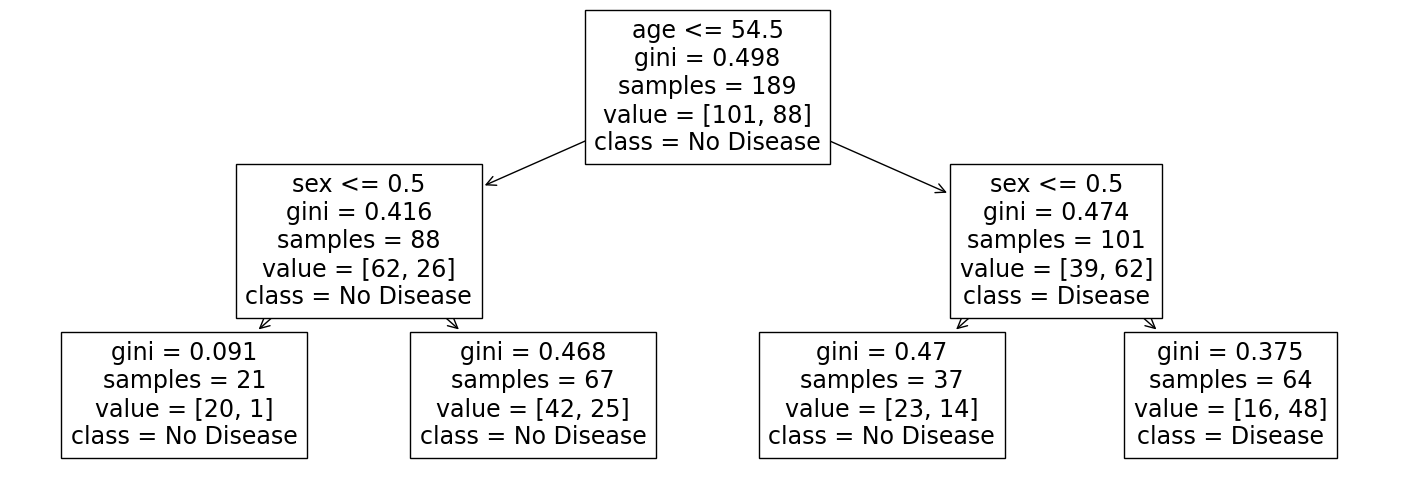

In [58]:
plt.figure(figsize=(18,6))
plot_tree(dt, feature_names=X.columns.tolist(),
          class_names=['No Disease','Disease'])#0,1
plt.show()
# age=60, sex=0, cholestraol = 90, bp=120 --> no

In [60]:
from sklearn.metrics import confusion_matrix, accuracy_score

In [62]:
y_train_pred = dt.predict(X_train)
y_test_pred = dt.predict(X_test)

In [64]:
# Max depth =2, min_sample_split=50
print("Train accuracy: ",round(100*accuracy_score(y_train, y_train_pred),2),"%")
print("Test accuracy: ",round(100*accuracy_score(y_test, y_test_pred),2),"%")

Train accuracy:  70.37 %
Test accuracy:  64.2 %


In [54]:
# Max depth =3, min_sample_split=100
print("Train accuracy: ",round(100*accuracy_score(y_train, y_train_pred),2),"%")
print("Test accuracy: ",round(100*accuracy_score(y_test, y_test_pred),2),"%")

Train accuracy:  70.37 %
Test accuracy:  64.2 %


In [44]:
# Max depth =3
print("Train accuracy: ",round(100*accuracy_score(y_train, y_train_pred),2),"%")
print("Test accuracy: ",round(100*accuracy_score(y_test, y_test_pred),2),"%")

Train accuracy:  74.07 %
Test accuracy:  60.49 %


In [26]:
# No Stopping Criteria
print("Train accuracy: ",round(100*accuracy_score(y_train, y_train_pred),2),"%")
print("Test accuracy: ",round(100*accuracy_score(y_test, y_test_pred),2),"%")

Train accuracy:  100.0 %
Test accuracy:  66.67 %


In [66]:
df=pd.read_csv("Housing.csv")

In [68]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [70]:
df["mainroad"]=df["mainroad"].map({"yes":1,"no":0})
df["guestroom"]=df["guestroom"].map({"yes":1,"no":0})
df["basement"]=df["basement"].map({"yes":1,"no":0})
df["hotwaterheating"]=df["hotwaterheating"].map({"yes":1,"no":0})
df["airconditioning"]=df["airconditioning"].map({"yes":1,"no":0})
df["prefarea"]=df["prefarea"].map({"yes":1,"no":0})
df["furnishingstatus"]=df["furnishingstatus"].map({"furnished":0,"semi-furnished":1,"unfurnished":2})

In [74]:
X=df.drop(["price"],axis=1)

y=df["price"]

In [76]:
X_train, X_test, y_train,y_test = train_test_split(X,y, test_size=0.3, random_state=42)

In [90]:
dt=DecisionTreeRegressor(max_depth=1)
dt.fit(X_train,y_train)

DecisionTreeRegressor(max_depth=1)

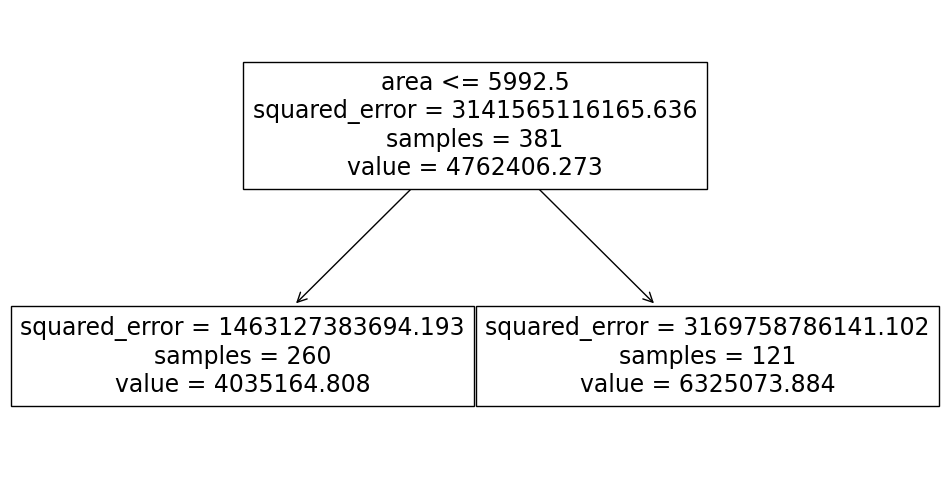

In [92]:
plt.figure(figsize=(12,6))
plot_tree(dt, feature_names=['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'])
plt.show()